In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
h_true = np.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=np.float64)
M = len(h_true)

# ==============================================================
# AR(1) generator with target eigenvalue spread
# ==============================================================
def ar1Input(a, N, sigma_v2=1.0):
  v = np.sqrt(sigma_v2) * np.random.randn(N)
  x = np.zeros(N)
  for n in range(1, N):
    x[n] = a * x[n-1] + v[n]
  x /= np.std(x)
  return x

In [3]:
def runSysID(
    model,
    spread=20,
    N=1000,
    sigma_n2=1e-4,
    n_runs=200,
    burnin=2000,
):
  """
  Monte-Carlo averaged MSE learning curve
  """
  a = adspfilter.ar1poleSpreadSearch(spread, M)

  # determine output length dynamically
  x_test = ar1Input(a, N + M)
  d_test = np.convolve(x_test, h_true)[:N]
  model.w = np.zeros(M)
  _, e_test, _ = model(x_test[:N], d_test, train=False)
  out_len = len(e_test)

  mse_runs = np.zeros((n_runs, out_len))

  for r in range(n_runs):
    x = ar1Input(a, N + M)        
    noise = np.sqrt(sigma_n2) * np.random.randn(N)
    d = np.convolve(x, h_true)[:N] + noise
    model.w = np.zeros(M)                      # reset weights
    y, e, _ = model(x[:N], d, train=True)
    mse_runs[r] = np.abs(e)**2

  mse_avg = np.mean(mse_runs, axis=0)
  burn = min(burnin, out_len // 2)
  misadj = (np.mean(mse_avg[burn:]) - sigma_n2) / sigma_n2

  return mse_avg, misadj

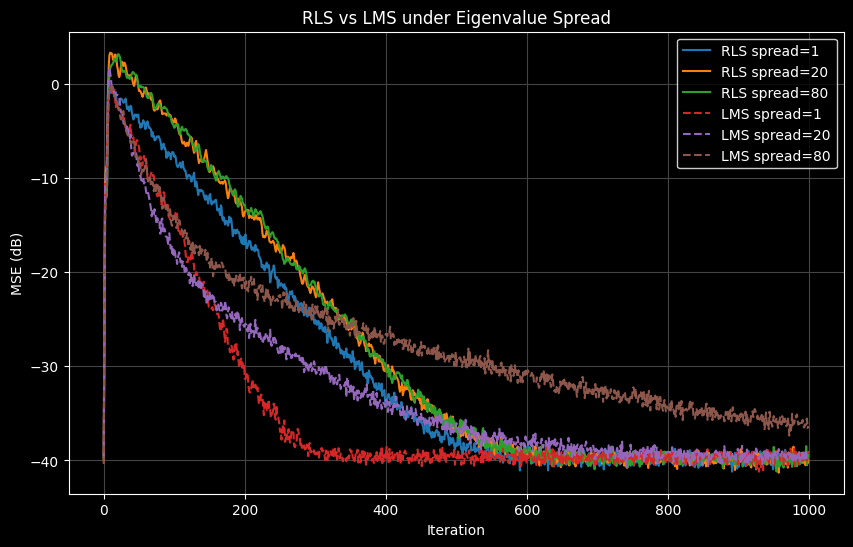

In [4]:
# RLS
rls = adspfilter.RLS(lam=0.99, mu=None, delta=1e-2, filter_order=M-1)
mse_r1, _ = runSysID(rls, spread=1)
mse_r20, _ = runSysID(rls, spread=20)
mse_r80, _ = runSysID(rls, spread=80)

# LMS
lms = adspfilter.LMS(mu=0.01, filter_order=M-1)
mse_l1, _ = runSysID(lms, spread=1)
mse_l20, _ = runSysID(lms, spread=20)
mse_l80, _ = runSysID(lms, spread=80)

plt.figure(figsize=(10,6))

# RLS
plt.plot(10*np.log10(mse_r1), label="RLS spread=1")
plt.plot(10*np.log10(mse_r20), label="RLS spread=20")
plt.plot(10*np.log10(mse_r80), label="RLS spread=80")

# LMS
plt.plot(10*np.log10(mse_l1), '--', label="LMS spread=1")
plt.plot(10*np.log10(mse_l20), '--', label="LMS spread=20")
plt.plot(10*np.log10(mse_l80), '--', label="LMS spread=80")

plt.legend()
plt.grid()
plt.title("RLS vs LMS under Eigenvalue Spread")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.show()

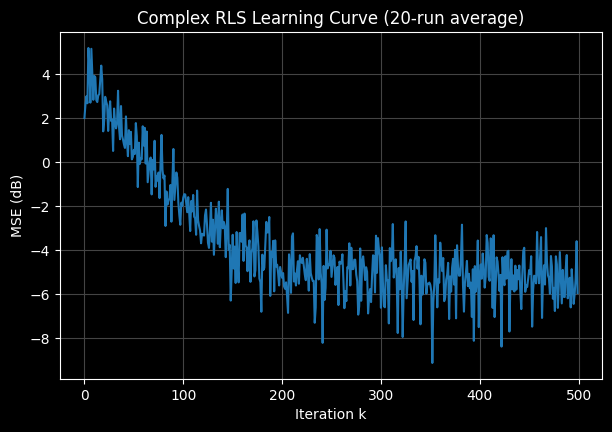

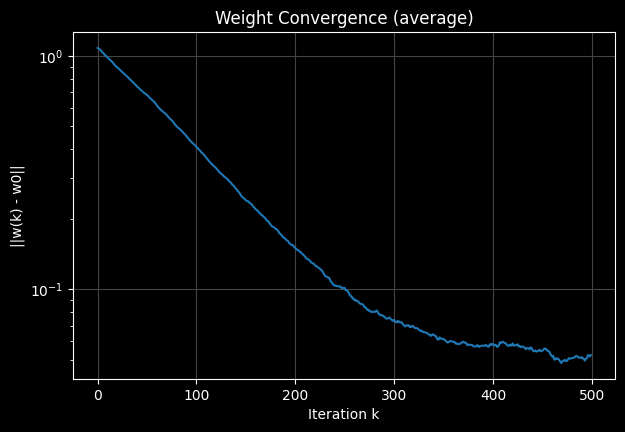

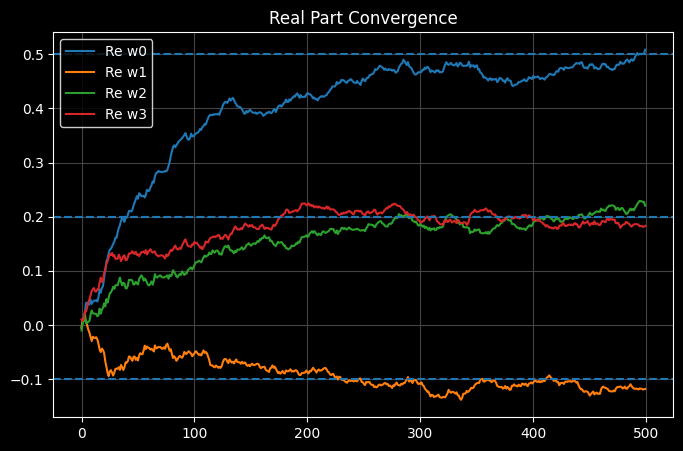

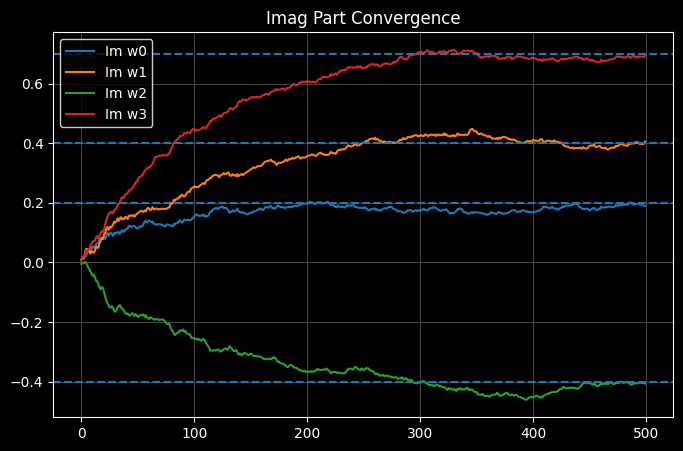

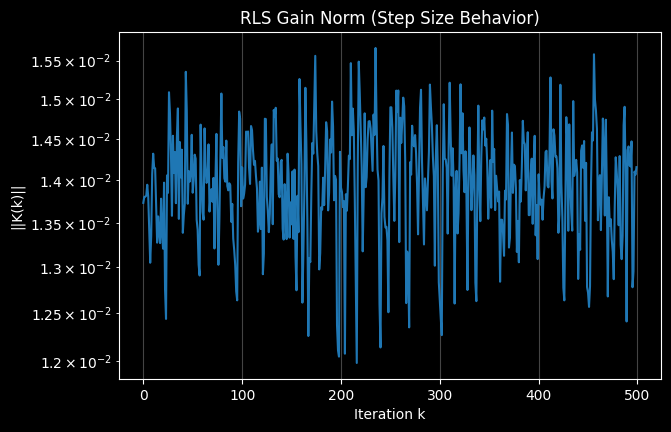

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Single RLS Run (with tracing)
# ================================
def rlsSysID4QAMTrace(n_iter=500, lam=0.99, sigma_n2=0.3):
    # True system
    w0 = np.array([
        0.5 + 0.2j,
       -0.1 + 0.4j,
        0.2 - 0.4j,
        0.2 + 0.7j
    ], dtype=np.complex128)

    n_taps = len(w0)

    # 4-QAM input: ±1 ± j
    x = (np.random.choice([-1, 1], size=n_iter + n_taps - 1) +
         1j * np.random.choice([-1, 1], size=n_iter + n_taps - 1))

    # Complex white Gaussian noise
    noise = np.sqrt(sigma_n2 / 2) * (
        np.random.randn(n_iter) + 1j * np.random.randn(n_iter)
    )

    # Desired signal
    d = np.zeros(n_iter, dtype=np.complex128)
    for k in range(n_iter):
        xk = x[k:k+n_taps][::-1]
        d[k] = np.vdot(w0, xk) + noise[k]

    # RLS initialization
    px = 2.0  # E[|x|^2] for 4-QAM
    delta = (1 - lam) / px
    S = delta * np.eye(n_taps, dtype=np.complex128)
    w = np.zeros(n_taps, dtype=np.complex128)

    # Traces
    w_hist = []
    err_norm = []
    mse_apriori = np.zeros(n_iter)
    gain_norm = []

    for k in range(n_iter):
        xk = x[k:k+n_taps][::-1]

        # a priori error
        e = d[k] - np.vdot(w, xk)
        mse_apriori[k] = np.abs(e) ** 2

        psi = S @ xk
        denom = lam + np.vdot(xk, psi)

        # RLS update
        S = (S - np.outer(psi, np.conj(psi)) / denom) / lam
        K = S @ xk
        w = w + np.conj(e) * K

        # Record
        w_hist.append(w.copy())
        err_norm.append(np.linalg.norm(w - w0))
        gain_norm.append(np.linalg.norm(K))

    return (
        np.array(w_hist),
        np.array(err_norm),
        np.array(gain_norm),
        mse_apriori,
        w0
    )


# ================================
# Ensemble Simulation
# ================================
n_exp = 20
n_iter = 500

curves = []
err_curves = []

# keep one run for visualization
w_hist_ref, err_ref, gain_ref, _, w0 = rlsSysID4QAMTrace()

for _ in range(n_exp):
    _, err_norm, _, mse, _ = rlsSysID4QAMTrace(n_iter=n_iter)
    curves.append(mse)
    err_curves.append(err_norm)

curves = np.array(curves)
err_curves = np.array(err_curves)

avg_curve = curves.mean(axis=0)
avg_err = err_curves.mean(axis=0)


# ================================
# Plot 1: Learning Curve (MSE)
# ================================
plt.figure(figsize=(7, 4.5))
plt.plot(10 * np.log10(avg_curve + 1e-12))
plt.xlabel("Iteration k")
plt.ylabel("MSE (dB)")
plt.title("Complex RLS Learning Curve (20-run average)")
plt.grid(True)


# ================================
# Plot 2: Weight Error Norm
# ================================
plt.figure(figsize=(7, 4.5))
plt.plot(avg_err)
plt.yscale('log')
plt.xlabel("Iteration k")
plt.ylabel("||w(k) - w0||")
plt.title("Weight Convergence (average)")
plt.grid(True)


# ================================
# Plot 3: Coefficient Convergence (Real)
# ================================
plt.figure(figsize=(8, 5))
for i in range(len(w0)):
    plt.plot(np.real(w_hist_ref[:, i]), label=f"Re w{i}")
    plt.axhline(np.real(w0[i]), linestyle='--')
plt.title("Real Part Convergence")
plt.legend()
plt.grid(True)


# ================================
# Plot 4: Coefficient Convergence (Imag)
# ================================
plt.figure(figsize=(8, 5))
for i in range(len(w0)):
    plt.plot(np.imag(w_hist_ref[:, i]), label=f"Im w{i}")
    plt.axhline(np.imag(w0[i]), linestyle='--')
plt.title("Imag Part Convergence")
plt.legend()
plt.grid(True)


# ================================
# Plot 5: Gain Norm (Insight)
# ================================
plt.figure(figsize=(7, 4.5))
plt.plot(gain_ref)
plt.yscale('log')
plt.xlabel("Iteration k")
plt.ylabel("||K(k)||")
plt.title("RLS Gain Norm (Step Size Behavior)")
plt.grid(True)


plt.show()

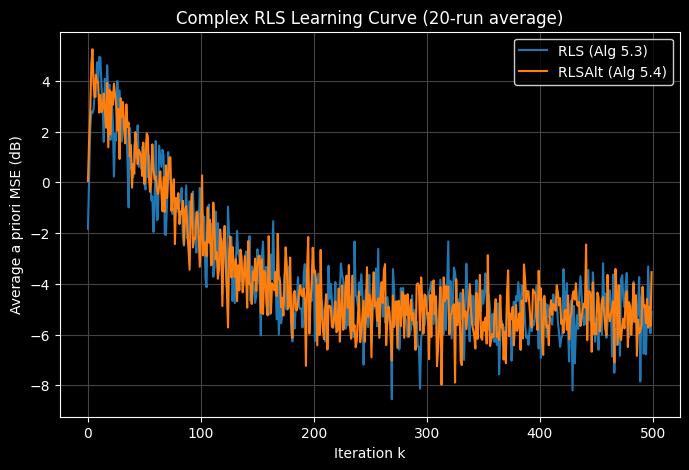

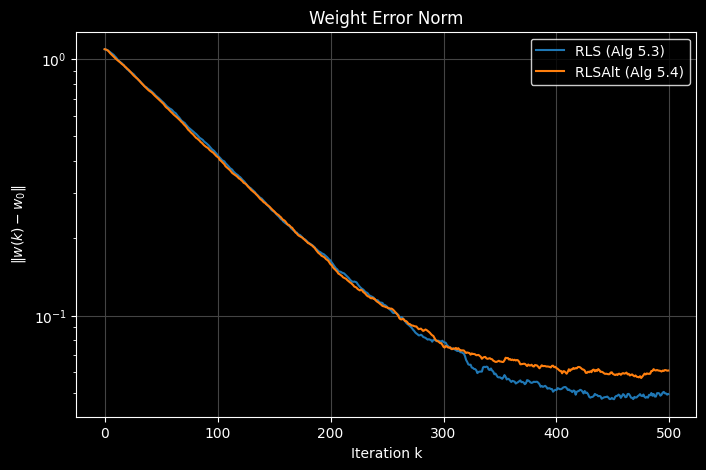

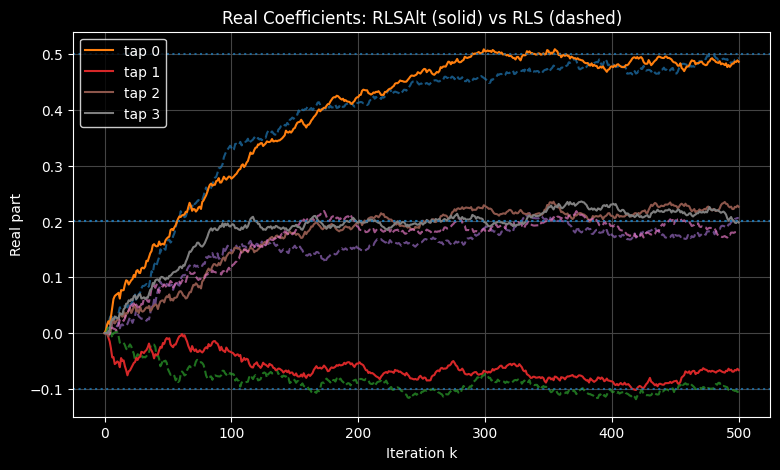

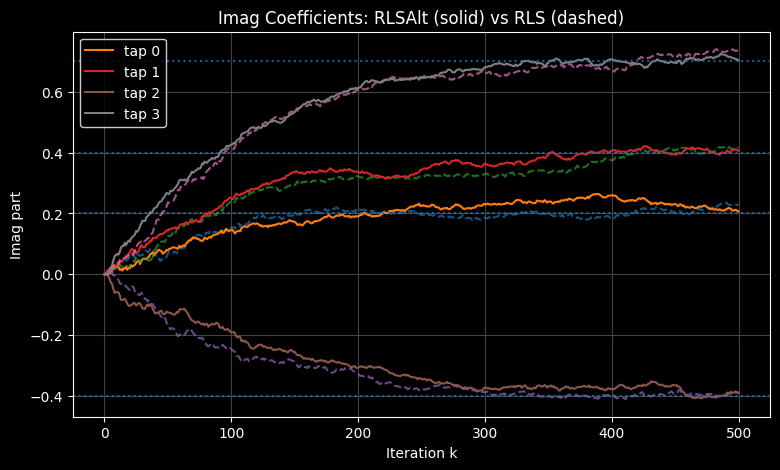

In [10]:
import numpy as np
import matplotlib.pyplot as plt

DTYPE = np.complex128

# =========================================
# Data generation MATCHED to class convention
# =========================================
def sysId4QamData(nIter=500, sigmaN2=0.3, dtype=DTYPE):
    w0 = np.array([
        0.5 + 0.2j,
        -0.1 + 0.4j,
        0.2 - 0.4j,
        0.2 + 0.7j
    ], dtype=dtype)

    nTaps = len(w0)
    x = (np.random.choice([-1, 1], size=nIter) +
         1j * np.random.choice([-1, 1], size=nIter)).astype(dtype)

    noise = np.sqrt(sigmaN2 / 2) * (np.random.randn(nIter) +
                                    1j * np.random.randn(nIter))
    noise = noise.astype(dtype)

    xPad = adspfilter._prepad(x, nTaps)
    d = np.zeros((nIter,), dtype=dtype)

    for k in range(nIter):
        xk = xPad[k:k + nTaps][::-1]
        d[k] = np.vdot(w0, xk) + noise[k]

    return x, d, w0


# =========================================
# Run one experiment
# =========================================
def runSysIdProb23(cls, nIter=500, lam=0.99, sigmaN2=0.3):
    x, d, w0 = sysId4QamData(nIter=nIter, sigmaN2=sigmaN2)

    px = 2.0
    delta = (1.0 - lam) / px

    alg = cls(
        filterOrder=len(w0) - 1,
        lam=lam,
        delta=delta,
        dtype=DTYPE,
    )

    y, e, wHist = alg(x, d, train=True)

    mse = np.abs(e) ** 2
    errNorm = np.linalg.norm(wHist - w0, axis=1)

    return mse, errNorm, wHist, w0


# =========================================
# Ensemble averaging
# =========================================
def ensembleRunProb23(cls, nExp=20, nIter=500, lam=0.99, sigmaN2=0.3):
    mseAll = []
    errAll = []

    for _ in range(nExp):
        mse, errNorm, _, _ = runSysIdProb23(
            cls=cls,
            nIter=nIter,
            lam=lam,
            sigmaN2=sigmaN2,
        )
        mseAll.append(mse)
        errAll.append(errNorm[:-1])

    mseAll = np.asarray(mseAll)
    errAll = np.asarray(errAll)

    return mseAll.mean(axis=0), errAll.mean(axis=0)


# =========================================
# Simulation parameters
# =========================================
nIter = 500
nExp = 20
lam = 0.99
sigmaN2 = 0.3

avgMseRls, avgErrRls = ensembleRunProb23(
    adspfilter.RLS,
    nExp=nExp,
    nIter=nIter,
    lam=lam,
    sigmaN2=sigmaN2
)

avgMseAlt, avgErrAlt = ensembleRunProb23(
    adspfilter.RLSAlt,
    nExp=nExp,
    nIter=nIter,
    lam=lam,
    sigmaN2=sigmaN2
)

_, _, wHistRls, w0 = runSysIdProb23(
    adspfilter.RLS,
    nIter=nIter,
    lam=lam,
    sigmaN2=sigmaN2
)

_, _, wHistAlt, _ = runSysIdProb23(
    adspfilter.RLSAlt,
    nIter=nIter,
    lam=lam,
    sigmaN2=sigmaN2
)


# =========================================
# Plot 1: Learning curves
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(10 * np.log10(avgMseRls + 1e-12), label="RLS (Alg 5.3)")
plt.plot(10 * np.log10(avgMseAlt + 1e-12), label="RLSAlt (Alg 5.4)")
plt.xlabel("Iteration k")
plt.ylabel("Average a priori MSE (dB)")
plt.title("Complex RLS Learning Curve (20-run average)")
plt.grid(True)
plt.legend()


# =========================================
# Plot 2: Weight-error norm
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(avgErrRls, label="RLS (Alg 5.3)")
plt.plot(avgErrAlt, label="RLSAlt (Alg 5.4)")
plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel(r"$\|w(k)-w_0\|$")
plt.title("Weight Error Norm")
plt.grid(True)
plt.legend()


# =========================================
# Plot 3: Real coefficient convergence
# =========================================
plt.figure(figsize=(9, 5))
for i in range(len(w0)):
    plt.plot(np.real(wHistRls[:, i]), "--", alpha=0.7)
    plt.plot(np.real(wHistAlt[:, i]), label=f"tap {i}")
    plt.axhline(np.real(w0[i]), linestyle=":", alpha=0.8)

plt.xlabel("Iteration k")
plt.ylabel("Real part")
plt.title("Real Coefficients: RLSAlt (solid) vs RLS (dashed)")
plt.grid(True)
plt.legend()


# =========================================
# Plot 4: Imag coefficient convergence
# =========================================
plt.figure(figsize=(9, 5))
for i in range(len(w0)):
    plt.plot(np.imag(wHistRls[:, i]), "--", alpha=0.7)
    plt.plot(np.imag(wHistAlt[:, i]), label=f"tap {i}")
    plt.axhline(np.imag(w0[i]), linestyle=":", alpha=0.8)

plt.xlabel("Iteration k")
plt.ylabel("Imag part")
plt.title("Imag Coefficients: RLSAlt (solid) vs RLS (dashed)")
plt.grid(True)
plt.legend()

plt.show()